In [121]:
%pip install matplotlib

import pandas as pd
import numpy as np
import matplotlib

# Load the data - specifying the tab delimiter
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\hotel-booking-data.txt", sep='\t')

# Preview the first 5 rows
print(df.head())

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 4.9 MB/s eta 0:00:02
   ----- ---------------------------------- 1.0/8.2 MB 2.3 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.2 MB 2.6 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.2 MB 2.4 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.2 MB 2.4 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.2 MB 1.7 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.2 MB 1.6 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.2 MB 1.6 MB/s eta 0:00:04
   --------------- ------------------------ 3.1/8.2 MB 1.6 MB/s eta 0:00:04
   ---------------- ----------------------- 3.4/8.2 MB 1.6 MB/s eta 0:00:03
   ------------------- -------------------- 3.9/8.2 MB 1.6 MB/s eta 0:00:03
   -------------------- -------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


         Date Company        Person Name  Room number
0  1-Jan-2022  Avamba  Anatole Ridehalgh       4008.0
1  1-Jan-2022    Fatz    Aldrich McKevin       2002.0
2  1-Jan-2022   Leexo    Stanley Hadrill       4012.0
3      Hotels     NaN                NaN          NaN
4  1-Jan-2022  Rhyzio       Lyndell Tice       1006.0


In [123]:
# Statistical summary of numerical columns (like room number)
print(df.describe())

# Count unique values in a specific column (e.g., company bookings)
print(df['Company'].value_counts())

       Room number
count   153.000000
mean   3079.326797
std    1718.791186
min    1001.000000
25%    2001.000000
50%    3008.000000
75%    4010.000000
max    7002.000000
Company
Leexo           3
Quinu           3
Fivechat        3
Eadel           2
Jayo            2
               ..
Twitterwire     1
Skiba           1
Tagpad          1
Innojam         1
Twitterworks    1
Name: count, Length: 114, dtype: int64


In [124]:
# Create a mask for rows where room number is NaN
mask = df['Room number'].isna()

In [125]:
# Use numpy to create a new column based on the mask
df['text_value'] = np.where(mask, df['Date'], np.nan)
df

,Date,Company,Person Name,Room number,text_value
0,1-Jan-2022,Avamba,Anatole Ridehalgh,4008.0,NaN
1,1-Jan-2022,Fatz,Aldrich McKevin,2002.0,NaN
2,1-Jan-2022,Leexo,Stanley Hadrill,4012.0,NaN
3,Hotels,NaN,NaN,NaN,Hotels
4,1-Jan-2022,Rhyzio,Lyndell Tice,1006.0,NaN
...,...,...,...,...,...
190,Cleartrip,NaN,NaN,NaN,Cleartrip
191,1-Jan-2022,Fivechat,Corabella Saye,4008.0,NaN
192,1-Jan-2022,Innojam,Leandra Potapczuk,5002.0,NaN
193,1-Jan-2022,Twitterworks,Valentia Ledson,1010.0,NaN


In [126]:
# Backfill the labels to associate data with the correct hotel/category
df['text_value'] = df['text_value'].bfill()
df

,Date,Company,Person Name,Room number,text_value
0,1-Jan-2022,Avamba,Anatole Ridehalgh,4008.0,Hotels
1,1-Jan-2022,Fatz,Aldrich McKevin,2002.0,Hotels
2,1-Jan-2022,Leexo,Stanley Hadrill,4012.0,Hotels
3,Hotels,NaN,NaN,NaN,Hotels
4,1-Jan-2022,Rhyzio,Lyndell Tice,1006.0,Booking
...,...,...,...,...,...
190,Cleartrip,NaN,NaN,NaN,Cleartrip
191,1-Jan-2022,Fivechat,Corabella Saye,4008.0,Hotels
192,1-Jan-2022,Innojam,Leandra Potapczuk,5002.0,Hotels
193,1-Jan-2022,Twitterworks,Valentia Ledson,1010.0,Hotels


In [127]:
# Drop rows that still have NaN values in the original data columns
df.dropna(inplace=True)

# Final clean data preview
df

,Date,Company,Person Name,Room number,text_value
0,1-Jan-2022,Avamba,Anatole Ridehalgh,4008.0,Hotels
1,1-Jan-2022,Fatz,Aldrich McKevin,2002.0,Hotels
2,1-Jan-2022,Leexo,Stanley Hadrill,4012.0,Hotels
4,1-Jan-2022,Rhyzio,Lyndell Tice,1006.0,Booking
5,1-Jan-2022,Eadel,Broderic Handscombe,3015.0,Booking
...,...,...,...,...,...
186,1-Jan-2022,Tagpad,Stephani Lafee,1015.0,Expedia
187,1-Jan-2022,Meevee,Victoria Lavery,7002.0,Expedia
191,1-Jan-2022,Fivechat,Corabella Saye,4008.0,Hotels
192,1-Jan-2022,Innojam,Leandra Potapczuk,5002.0,Hotels


In [128]:
df.value_counts('text_value')


text_value
Expedia             48
Hotels              39
Booking             24
Travel Agent 007    12
Cleartrip           11
Name: count, dtype: int64

<Axes: >

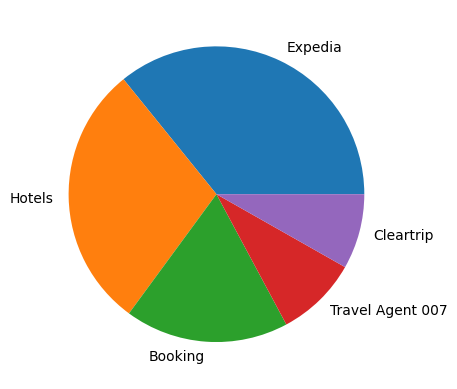

In [132]:
df2 = df.value_counts('text_value')
df2.plot.pie()

<Axes: xlabel='text_value'>

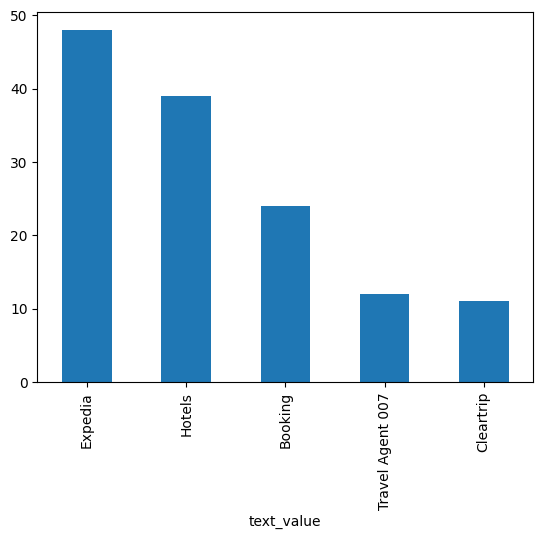

In [136]:
df2 = df.value_counts('text_value')
df2.plot.bar()

<Axes: >

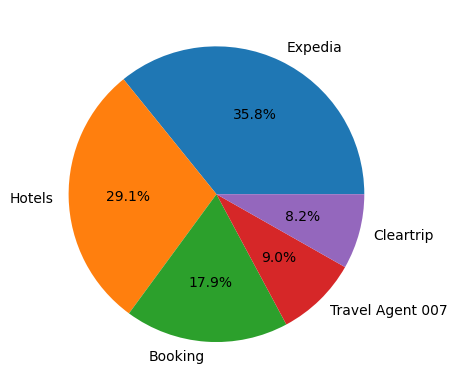

In [133]:
# The 'autopct' parameter adds the percentage labels
# '%1.1f%%' means: 1 decimal place, floating point, followed by a '%' sign
df2 = df.value_counts('text_value')
df2.plot.pie(autopct='%1.1f%%')